# Stage 2: Pitch (F0) Estimation via Autocorrelation

This stage estimates the fundamental frequency (F0) of voiced frames using short-time autocorrelation, and constructs a pitch contour for the utterance from the per-frame estimates.

In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

DATA_ROOT = "../data/fluent_speech_commands_dataset"
WAV_PATH = f"{DATA_ROOT}/wavs/speakers/2BqVo8kVB2Skwgyb/ac4fca80-447a-11e9-a9a5-5dbec3b8816a.wav"
TRANSCRIPT = "Bring socks"

y, sr = librosa.load(WAV_PATH, sr=None)

FRAME_MS, HOP_MS = 25, 10
frame_len = int(sr * FRAME_MS / 1000)
hop_len = int(sr * HOP_MS / 1000)

frames = librosa.util.frame(y, frame_length=frame_len, hop_length=hop_len)
n_frames = frames.shape[1]
frame_times = (np.arange(n_frames) * hop_len + frame_len / 2) / sr

## Voiced/unvoiced/silence labeling

Pitch is only defined for voiced frames, so the Stage 1 short-time energy and zero-crossing rate classification is reproduced here to identify which frames autocorrelation should be applied to.

In [2]:
ste = np.sum(frames.astype(np.float64) ** 2, axis=0)
ste_db = 10 * np.log10(ste + 1e-10)
signs = np.sign(frames)
signs[signs == 0] = 1
zcr = np.mean(np.abs(np.diff(signs, axis=0)) / 2, axis=0)

noise_floor_db = np.percentile(ste_db, 15)
energy_thresh_db = noise_floor_db + 10
is_speech = ste_db > energy_thresh_db
zcr_thresh = np.percentile(zcr[is_speech], 70)

labels = np.full(n_frames, "S", dtype="<U1")
labels[is_speech & (zcr <= zcr_thresh)] = "V"
labels[is_speech & (zcr > zcr_thresh)] = "U"

print(f"Voiced frames: {int(np.sum(labels == 'V'))} / {n_frames}")

Voiced frames: 75 / 174


## Short-time autocorrelation

For a frame of samples $x[n]$, the autocorrelation at lag $k$ is

$$r[k] = \sum_{n} x[n]\, x[n+k]$$

For a periodic (voiced) frame, $r[k]$ exhibits a local maximum at $k$ equal to the pitch period, in addition to the trivial global maximum at $k=0$. The fundamental frequency is then $F_0 = f_s / k_{\text{peak}}$, where $f_s$ is the sampling rate.

The search for $k_{\text{peak}}$ is restricted to lags corresponding to a plausible fundamental-frequency range for adult speech, approximately 70-400 Hz, to avoid octave errors that arise from spurious peaks at integer multiples of the true period. The ratio $r[k_{\text{peak}}] / r[0]$ is retained as a confidence measure for each estimate, since a frame with weak or ambiguous periodicity yields a comparatively low peak.

In [3]:
F0_MIN, F0_MAX = 70, 400  # Hz; approximate range for adult speech
min_lag = int(sr / F0_MAX)
max_lag = int(sr / F0_MIN)
CONF_THRESH = 0.3  # minimum r[k_peak]/r[0] to accept an estimate as reliable

def short_time_acf(frame, max_lag):
    frame = frame - frame.mean()
    return np.array([np.dot(frame[:len(frame) - k], frame[k:]) for k in range(max_lag + 1)])

f0_contour = np.full(n_frames, np.nan)
confidence = np.full(n_frames, np.nan)

for i in range(n_frames):
    if labels[i] != "V":
        continue
    r = short_time_acf(frames[:, i].astype(np.float64), max_lag)
    if r[0] <= 0:
        continue
    segment = r[min_lag:max_lag + 1]
    peak_lag = min_lag + int(np.argmax(segment))
    confidence[i] = segment.max() / r[0]
    f0_contour[i] = sr / peak_lag

reliable = confidence >= CONF_THRESH
print(f"Voiced frames with an F0 estimate: {int(np.sum(~np.isnan(f0_contour)))}")
print(f"Reliable estimates (confidence >= {CONF_THRESH}): {int(np.sum(reliable))}")

Voiced frames with an F0 estimate: 75
Reliable estimates (confidence >= 0.3): 63


## Single-frame autocorrelation

The autocorrelation function of one representative voiced frame is shown below, with the search range and the selected peak marked.

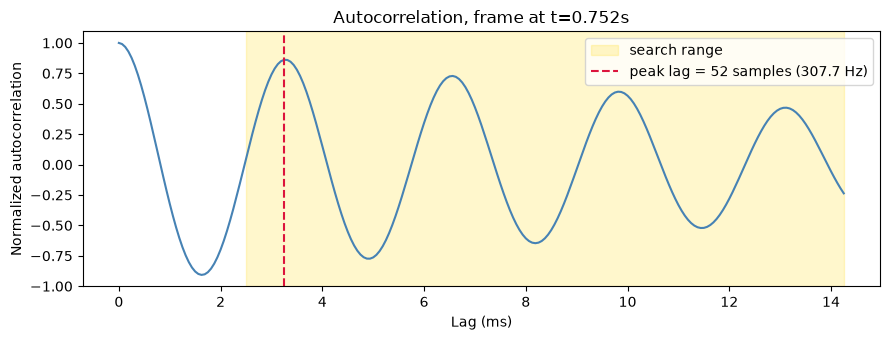

In [4]:
example_idx = np.argmin(np.abs(frame_times - 0.75))
example_frame = frames[:, example_idx].astype(np.float64)
r_example = short_time_acf(example_frame, max_lag)
peak_lag_example = min_lag + int(np.argmax(r_example[min_lag:max_lag + 1]))

fig, ax = plt.subplots(figsize=(9, 3.5))
lags_ms = np.arange(max_lag + 1) / sr * 1000
ax.plot(lags_ms, r_example / r_example[0], color="steelblue")
ax.axvspan(min_lag / sr * 1000, max_lag / sr * 1000, color="gold", alpha=0.2, label="search range")
ax.axvline(peak_lag_example / sr * 1000, color="crimson", linestyle="--",
           label=f"peak lag = {peak_lag_example} samples ({sr/peak_lag_example:.1f} Hz)")
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Normalized autocorrelation")
ax.set_title(f"Autocorrelation, frame at t={frame_times[example_idx]:.3f}s")
ax.legend()
fig.tight_layout()
plt.show()

## Pitch contour

The estimated F0 is plotted over time for all voiced frames, alongside the waveform for reference. Estimates below the confidence threshold are shown as lighter, smaller markers.

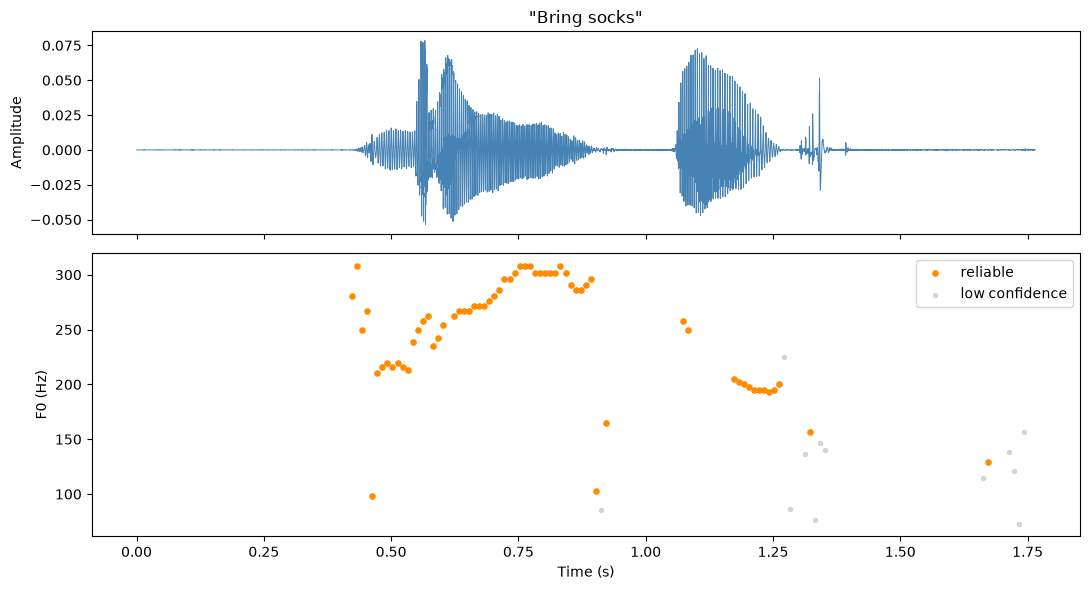

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                          gridspec_kw={"height_ratios": [1, 1.4]})

t = np.arange(len(y)) / sr
axes[0].plot(t, y, linewidth=0.7, color="steelblue")
axes[0].set_ylabel("Amplitude")
axes[0].set_title(f'"{TRANSCRIPT}"')

axes[1].scatter(frame_times[reliable], f0_contour[reliable], s=14, color="darkorange", label="reliable")
axes[1].scatter(frame_times[~np.isnan(f0_contour) & ~reliable], f0_contour[~np.isnan(f0_contour) & ~reliable],
                 s=8, color="lightgray", label="low confidence")
axes[1].set_ylabel("F0 (Hz)")
axes[1].set_xlabel("Time (s)")
axes[1].legend()

fig.tight_layout()
plt.show()

## Results

Of the 75 voiced frames, 75 yielded an autocorrelation-based F0 estimate, of which 63 met the confidence threshold (normalized peak height >= 0.3). Reliable estimates for the vowel in "Bring" range from approximately 210 Hz to 310 Hz, first rising and then falling across the segment, tracing the word's pitch contour; the vowel in "socks" shows a declining trend from approximately 258 Hz to 195 Hz. The overall F0 range is consistent with a higher-pitched adult voice.

The frames excluded by the confidence threshold are concentrated at segment boundaries (transitions into or out of unvoiced regions and silence) and near the end of the utterance, consistent with weaker or less regular glottal periodicity in these regions. One reliable estimate, at t=0.463s (F0 = 98.2 Hz), is anomalous relative to its immediate neighbors (approximately 210-220 Hz) and is consistent with an octave error, illustrating the failure mode the search-range restriction is intended to reduce but does not eliminate entirely.